# Análise exploratória

In [1]:
#Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

#Carregamento dos dados
df = pd.read_csv('credit_data.csv')
df.head(30)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


In [2]:
#Informações gerais do dataset
print(f'Shape: {df.shape}')
print(f'\nNulos:\n{df.isnull().sum()}')
print(f'\nDuplicados: {df.duplicated().sum()}')
print(f'\nTipos:\n{df.dtypes}')

Shape: (2000, 5)

Nulos:
clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

Duplicados: 0

Tipos:
clientid      int64
income      float64
age         float64
loan        float64
default       int64
dtype: object


In [3]:
#Estatística descritiva
df.describe().round(2)

,clientid,income,age,loan,default
count,2000.00,2000.00,1997.00,2000.00,2000.00
mean,1000.50,45331.60,40.81,4444.37,0.14
std,577.49,14326.33,13.62,3045.41,0.35
min,1.00,20014.49,-52.42,1.38,0.00
25%,500.75,32796.46,28.99,1939.71,0.00
50%,1000.50,45789.12,41.32,3974.72,0.00
75%,1500.25,57791.28,52.59,6432.41,0.00
max,2000.00,69995.69,63.97,13766.05,1.00


In [4]:
#Corrigindo idades negativas
df['age'] = df['age'].abs()

#Preenchendo nulos com a mediana
mediana_age = df['age'].median()
df['age'] = df['age'].fillna(mediana_age)

print(f'Mediana usada para preencher nulos: {mediana_age:.2f} anos')
print(f'Nulos restantes: {df["age"].isnull().sum()}')
print(f'Idade mínima após correção: {df["age"].min():.2f}')
print(f'Idade máxima após correção: {df["age"].max():.2f}')

Mediana usada para preencher nulos: 41.35 anos
Nulos restantes: 0
Idade mínima após correção: 18.06
Idade máxima após correção: 63.97


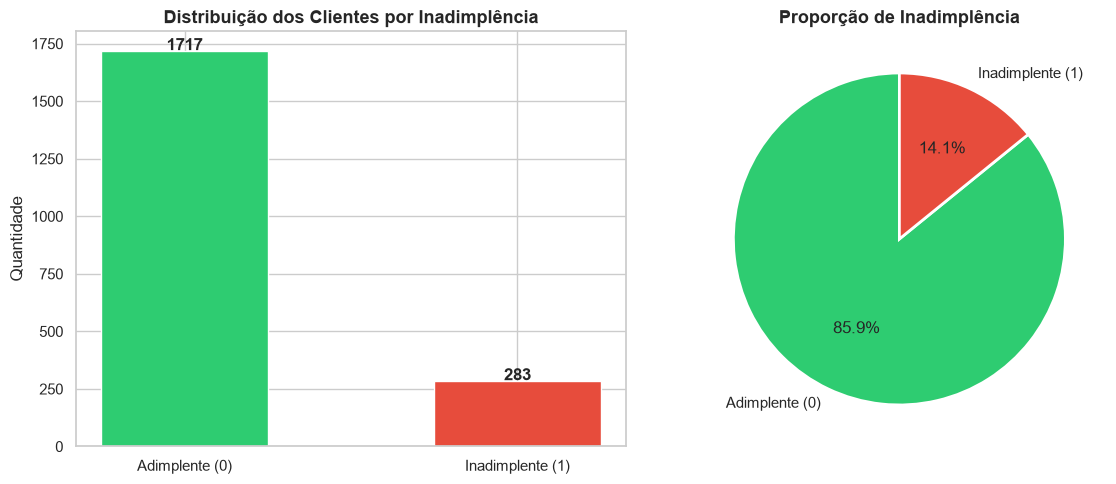

In [5]:
#Distribuição da variável alvo: default (0 = pagou, 1 = inadimplente)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

contagem = df['default'].value_counts()
labels = ['Adimplente (0)', 'Inadimplente (1)']

axes[0].bar(labels, contagem.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Distribuição dos Clientes por Inadimplência', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(contagem.values, labels=labels, colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporção de Inadimplência', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

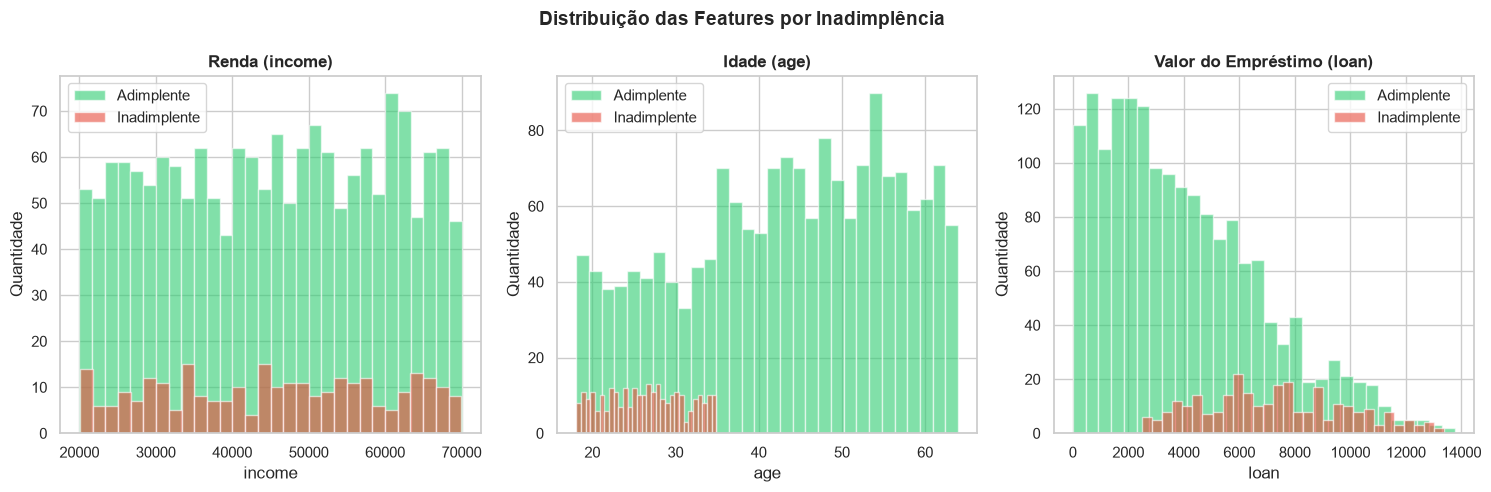

In [6]:
#Distribuição de income, age e loan por inadimplência
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features = ['income', 'age', 'loan']
titulos = ['Renda (income)', 'Idade (age)', 'Valor do Empréstimo (loan)']
cores = {0: '#2ecc71', 1: '#e74c3c'}

for ax, feat, titulo in zip(axes, features, titulos):
    for val, cor in cores.items():
        subset = df[df['default'] == val][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=cor,
                label='Adimplente' if val == 0 else 'Inadimplente', edgecolor='white')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Quantidade')
    ax.legend()

plt.suptitle('Distribuição das Features por Inadimplência', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

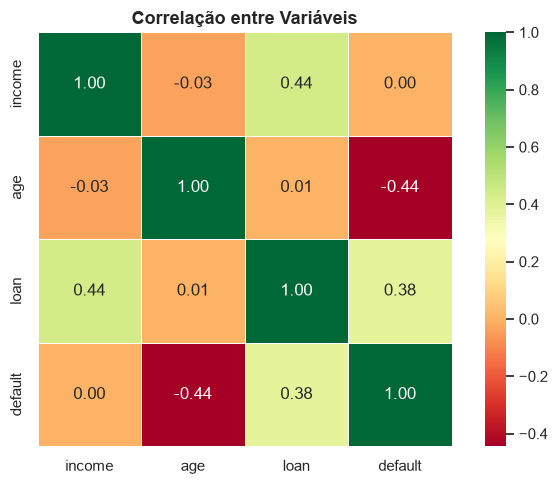

In [7]:
#Mapa de correlação entre as variáveis
plt.figure(figsize=(7, 5))
sns.heatmap(df[['income', 'age', 'loan', 'default']].corr(),
            annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True)
plt.title('Correlação entre Variáveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Aplicando os modelos

In [8]:
#importação das bibliotecas
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


In [9]:
#Separando features e target
from sklearn.preprocessing import StandardScaler

X = df[['income', 'age', 'loan']].values
y = df['default'].values

In [10]:
#Normalizando os dados
scaler = StandardScaler()
X_credit = scaler.fit_transform(X)
y_credit = y

print(f'Shape X: {X_credit.shape}')
print(f'Shape y: {y_credit.shape}')
print(f'\nPrimeiras linhas normalizadas:')
print(X_credit[:3])

Shape X: (2000, 3)
Shape y: (2000,)

Primeiras linhas normalizadas:
[[ 1.45393393  1.36493491  1.20281942]
 [-0.76217555  0.54258169  0.69642695]
 [ 0.83682073  1.67358793  1.17471147]]


Árvore de Decisão

In [11]:
#Definindo os parâmetros da árvore de decisão
parametros = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [12]:
#Aplicando GridSearchCV para encontrar os melhores parâmetros da árvore de decisão
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'criterion': 'gini', 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}
0.986


Random Forest


In [13]:
#Definindo os parâmetros do Random Forest
parametros = {'criterion': ['gini', 'entropy'],
              'n_estimators': [10, 40, 100, 150],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 5, 10]}

In [14]:
#Aplicando GridSearchCV para encontrar os melhores parâmetros do Random Forest
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'criterion': 'gini', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
0.9890000000000001


K- Nearest Neighbors (KNN)

In [15]:
#Definindo os parâmetros do KNN

parametros = {'n_neighbors': [3, 5, 10, 20],
              'p': [1 , 2]}

In [16]:
#Aplicando GridSearchCV para encontrar os melhores parâmetros do KNN
grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'n_neighbors': 5, 'p': 2}
0.9804999999999999


Regressão Logística

In [17]:
#Definindo os parâmetros da Regressão Logística
parametros = {'tol': [0.0001, 0.00001, 0.000001],
              'C': [1.0, 1.5, 2.0],
              'solver': ['lbfgs', 'sag', 'saga']}

In [18]:
#Aplicando GridSearchCV para encontrar os melhores parâmetros da Regressão Logística
grid_search = GridSearchCV(estimator=LogisticRegression(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.5, 'solver': 'lbfgs', 'tol': 0.0001}
0.9484999999999999


Support Vector Machine (SVM)

In [19]:
#Definindo os parâmetros do SVM
parametros = {'tol': [0.001, 0.0001, 0.00001],
              'C': [1.0, 1.5, 2.0],
              'kernel': ['rbf', 'linear','poly', 'sigmoid' ]}

In [20]:
#Aplicando GridSearchCV para encontrar os melhores parâmetros do SVM
grid_search = GridSearchCV(estimator=SVC(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'C': 1.5, 'kernel': 'rbf', 'tol': 0.001}
0.9845


Redes Neurais

In [21]:
import warnings
warnings.filterwarnings('ignore')

parametros = {'activation': ['relu', 'logistic', 'tanh'],
              'solver': ['adam', 'sgd'],
              'batch_size': [10, 56],
              'max_iter': [500]}

In [22]:
grid_search = GridSearchCV(estimator=MLPClassifier(), param_grid=parametros)
grid_search.fit(X_credit, y_credit)
melhores_parametros = grid_search.best_params_
melhor_resultado = grid_search.best_score_
print(melhores_parametros)
print(melhor_resultado)

{'activation': 'relu', 'batch_size': 56, 'max_iter': 500, 'solver': 'adam'}
0.9970000000000001


Validação Cruzada

In [23]:
from sklearn.model_selection import cross_val_score, KFold

In [24]:
import warnings
warnings.filterwarnings('ignore')

resultados_arvore = []
resultados_random_forest = []
resultados_knn = []
resultados_logistica = []
resultados_svm = []
resultados_rede_neural = []

for i in range(30):
    print(i)
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    arvore = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, splitter='best')
    scores = cross_val_score(arvore, X_credit, y_credit, cv = kfold)
    #print(scores)
    #print(scores.mean())
    resultados_arvore.append(scores.mean())

    random_forest = RandomForestClassifier(criterion='entropy', min_samples_leaf=1, min_samples_split=5, n_estimators=10)
    scores = cross_val_score(random_forest, X_credit, y_credit, cv = kfold)
    resultados_random_forest.append(scores.mean())

    knn = KNeighborsClassifier()
    scores = cross_val_score(knn, X_credit, y_credit, cv = kfold)
    resultados_knn.append(scores.mean())

    logistica = LogisticRegression(C = 11.0, solver = 'lbfgs', tol = 0.0001)
    scores = cross_val_score(logistica, X_credit, y_credit, cv = kfold)
    resultados_logistica.append(scores.mean())

    svm = SVC(kernel = 'rbf', C = 2.0)
    scores = cross_val_score(svm, X_credit, y_credit, cv = kfold)
    resultados_svm.append(scores.mean())

    rede_neural = MLPClassifier(activation = 'relu', batch_size = 56, solver = 'adam')
    scores = cross_val_score(rede_neural, X_credit, y_credit, cv = kfold)
    resultados_rede_neural.append(scores.mean())

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


Combinação de classificadores

In [26]:
from sklearn.ensemble import VotingClassifier
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Criando os modelos com os melhores parâmetros encontrados pelo GridSearchCV
arvore = DecisionTreeClassifier(criterion='gini', min_samples_leaf=1,
                                 min_samples_split=5, splitter='best')
random_forest = RandomForestClassifier(criterion='gini', min_samples_leaf=1,
                                        min_samples_split=5, n_estimators=100)
knn = KNeighborsClassifier(n_neighbors=5, p=2)
logistica = LogisticRegression(C=1.5, solver='lbfgs', tol=0.0001)
svm = SVC(C=1.5, kernel='rbf', tol=0.001, probability=True)
rede_neural = MLPClassifier(activation='relu', batch_size=56,
                             solver='adam', max_iter=500)

# Combinando todos os modelos em um VotingClassifier
voting = VotingClassifier(estimators=[
    ('Arvore de Decisão', arvore),
    ('Random Forest', random_forest),
    ('KNN', knn),
    ('Regressão Logística', logistica),
    ('SVM', svm),
    ('Rede Neural', rede_neural)
], voting='soft')

# Avaliando com validação cruzada — 30 iterações
resultados_voting = []
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)
    scores = cross_val_score(voting, X_credit, y_credit, cv=kfold)
    resultados_voting.append(scores.mean())

print(f'Média: {np.mean(resultados_voting):.4f}')
print(f'Desvio padrão: {np.std(resultados_voting):.4f}')

Média: 0.9920
Desvio padrão: 0.0010


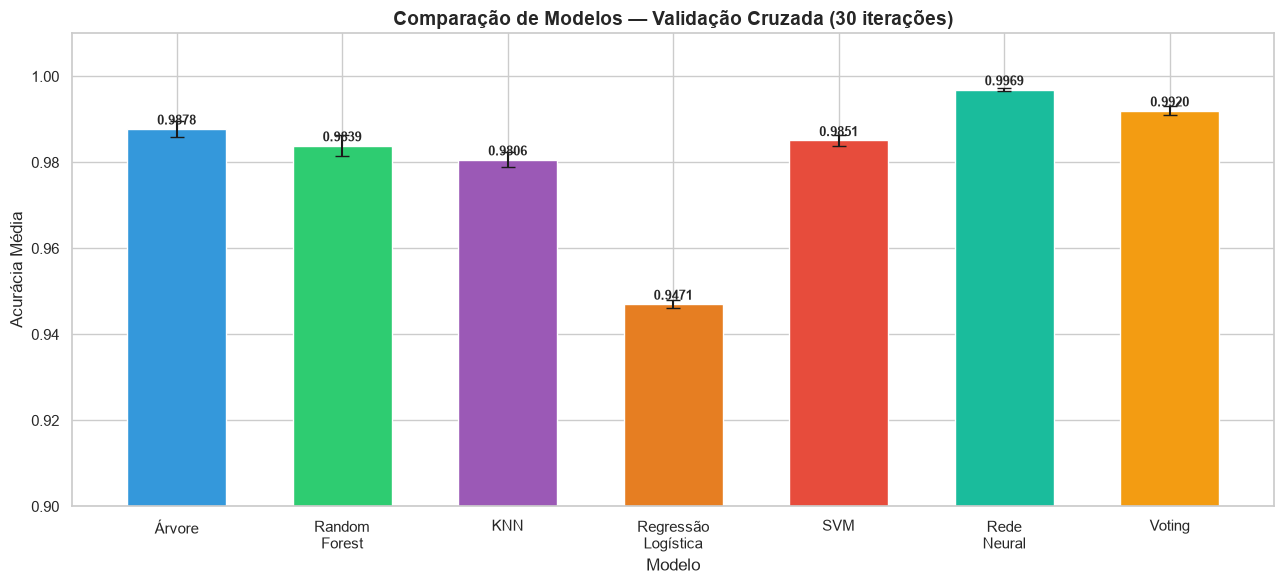

In [27]:
#Comparando a performance de todos os modelos
import matplotlib.pyplot as plt
import numpy as np

modelos = ['Árvore', 'Random\nForest', 'KNN', 'Regressão\nLogística', 'SVM', 'Rede\nNeural', 'Voting']
medias = [
    np.mean(resultados_arvore),
    np.mean(resultados_random_forest),
    np.mean(resultados_knn),
    np.mean(resultados_logistica),
    np.mean(resultados_svm),
    np.mean(resultados_rede_neural),
    np.mean(resultados_voting)
]
desvios = [
    np.std(resultados_arvore),
    np.std(resultados_random_forest),
    np.std(resultados_knn),
    np.std(resultados_logistica),
    np.std(resultados_svm),
    np.std(resultados_rede_neural),
    np.std(resultados_voting)
]

cores = ['#3498db','#2ecc71','#9b59b6','#e67e22','#e74c3c','#1abc9c','#f39c12']

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(modelos, medias, color=cores, edgecolor='white', width=0.6, yerr=desvios, capsize=5)

for bar, media in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{media:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylim(0.90, 1.01)
ax.set_title('Comparação de Modelos — Validação Cruzada (30 iterações)', fontsize=14, fontweight='bold')
ax.set_ylabel('Acurácia Média')
ax.set_xlabel('Modelo')
plt.tight_layout()
plt.show()

# Conclusão

Este notebook comparou **6 algoritmos de classificação** para prever inadimplência de clientes de crédito, utilizando três abordagens: **GridSearchCV** para otimização de parâmetros, **Validação Cruzada com KFold** para avaliação de robustez e **VotingClassifier** para combinação dos modelos.

## Resultados do GridSearchCV

| Modelo | Acurácia | Melhores Parâmetros |
|--------|----------|---------------------|
| Árvore de Decisão | 98.65% | criterion=gini, splitter=best, min_samples_split=5 |
| Random Forest | 98.90% | criterion=gini, n_estimators=100, min_samples_split=5 |
| KNN | 98.04% | n_neighbors=5, p=2 |
| Regressão Logística | 94.84% | C=1.5, solver=lbfgs |
| SVM | 98.45% | C=1.5, kernel=rbf |
| **Redes Neurais** | **99.70%** | activation=relu, batch_size=56, solver=adam |

## Resultado do VotingClassifier

| Técnica | Acurácia Média | Desvio Padrão |
|---------|---------------|---------------|
| Voting (combinação dos 6 modelos) | **99.20%** | 0.0010 |

## Interpretação

- **Redes Neurais** foi o modelo mais preciso com **99.70%** o melhor resultado individual
- **Random Forest** surpreendeu positivamente chegando a **98.90%**, superando SVM e KNN
- **Regressão Logística** foi o mais fraco (94.85%) esperado, pois dados de crédito têm relações não-lineares que modelos simples não capturam bem
- O **VotingClassifier** combinando todos os 6 modelos atingiu **99.20%** superior à maioria dos modelos individuais, mas não superou a Rede Neural isolada, pois a Regressão Logística mais fraca puxa levemente o resultado para baixo
- Os desvios padrão baixos indicam resultados **estáveis e confiáveis** em qualquer divisão dos dados